<a href="https://colab.research.google.com/github/Amezo/my-portfolio/blob/main/depth_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# Start Data Engineering

In [ ]:
# import os
# import cv2
# import numpy as np
# import pandas as pd
# from tqdm import tqdm
# from google.colab import drive

# # 1. Montage du Drive
# drive.mount('/content/drive')

# # 2. Configuration des chemins
# DATASET_ROOT = "/content/drive/MyDrive/Colab Notebooks/Code/DL/Depth/datasets"

# # Paramètres de conversion
# MIN_DEPTH_M = 0.16
# MAX_DEPTH_M = 300.0
# IMG_EXT = ".jpg"

# def fast_convert_depth(img):
#     """Convertit l'image de profondeur RGB en mètres."""
#     img = img.astype(float)
#     r, g, b = img[:,:,2], img[:,:,1], img[:,:,0]

#     hue = np.zeros_like(r)
#     mask_r = (r >= g) & (r >= b)
#     mask_g = (g >= r) & (g >= b) & ~mask_r
#     mask_b = (b >= g) & (b >= r) & ~mask_r & ~mask_g

#     hue[mask_r & (g >= b)] = g[mask_r & (g >= b)] - b[mask_r & (g >= b)]
#     hue[mask_r & (g < b)] = (g[mask_r & (g < b)] - b[mask_r & (g < b)]) + 1529
#     hue[mask_g] = b[mask_g] - r[mask_g] + 510
#     hue[mask_b] = r[mask_b] - g[mask_b] + 1020

#     # Conversion Hue -> Millimètres puis -> Mètres
#     depth_m = (hue * 3.5) / 1000.0
#     return depth_m

# def process_all_splits():
#     splits = ["train", "val", "test"]

#     for split in splits:
#         split_dir = os.path.join(DATASET_ROOT, split)
#         if not os.path.exists(split_dir):
#             print(f"Skipping {split}: folder not found.")
#             continue

#         print(f"\n--- Processing Split: {split.upper()} ---")

#         # Dossiers source
#         left_rgb_dir = os.path.join(split_dir, "Depth_left")
#         right_rgb_dir = os.path.join(split_dir, "Depth_right")

#         # Dossiers destination (vos .npy)
#         out_left = os.path.join(split_dir, "Depth_left_m")
#         out_right = os.path.join(split_dir, "Depth_right_m")
#         out_masks = os.path.join(split_dir, "masks")

#         for d in [out_left, out_right, out_masks]:
#             os.makedirs(d, exist_ok=True)

#         files = [f for f in os.listdir(left_rgb_dir) if f.endswith(IMG_EXT)]

#         for fname in tqdm(files, desc=f"Converting {split}"):
#             try:
#                 base_id = os.path.splitext(fname)[0]

#                 # 1. Traitement GAUCHE
#                 img_l = cv2.imread(os.path.join(left_rgb_dir, fname))
#                 if img_l is None: continue
#                 dL = fast_convert_depth(img_l)
#                 np.save(os.path.join(out_left, base_id + ".npy"), dL)

#                 # 2. Traitement DROIT
#                 # 2. Traitement DROIT
#                 # On remplace '_left' par '_right' dans le nom du fichier si nécessaire
#                 fname_right = fname.replace("_left", "_right").replace("_L", "_R")
#                 path_r = os.path.join(right_rgb_dir, fname_right)

#                 if not os.path.exists(path_r):
#                     # Si on ne trouve toujours pas, on essaie le nom exact (votre code actuel)
#                     path_r = os.path.join(right_rgb_dir, fname)

#                 img_r = cv2.imread(path_r)
#                 if img_r is not None:
#                     dR = fast_convert_depth(img_r)
#                     np.save(os.path.join(out_right, base_id.replace("_left", "_right") + ".npy"), dR)
#                 else:
#                     print(f"Image droite introuvable pour : {fname}")
#                 # On cherche le fichier correspondant à droite
#                 path_r = os.path.join(right_rgb_dir, fname)
#                 img_r = cv2.imread(path_r)
#                 if img_r is not None:
#                     dR = fast_convert_depth(img_r)
#                     np.save(os.path.join(out_right, base_id + ".npy"), dR)

#                 # 3. Masque (basé sur la gauche)
#                 mask = ((dL > MIN_DEPTH_M) & (dL < MAX_DEPTH_M)).astype(np.uint8) * 255
#                 cv2.imwrite(os.path.join(out_masks, base_id + "_mask.png"), mask)

#             except Exception as e:
#                 print(f"Error on {fname}: {e}")

#     print("\n Conversion terminée pour tous les splits !")

# if __name__ == "__main__":
#     process_all_splits()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

--- Processing Split: TRAIN ---


Converting train: 100%|██████████| 16182/16182 [3:59:12<00:00,  1.13it/s]



--- Processing Split: VAL ---


Converting val: 100%|██████████| 5034/5034 [55:50<00:00,  1.50it/s]



--- Processing Split: TEST ---


Converting test: 100%|██████████| 5801/5801 [1:10:20<00:00,  1.37it/s]


 Conversion terminée pour tous les splits !


In [ ]:
!pip install torch torchvision --extra-index-url https://download.pytorch.org/whl/cu121 -q  > /dev/null 2>&1
!pip install matplotlib numpy pandas opencv-python -q  > /dev/null 2>&1
!pip install reportlab matplotlib pandas -q  > /dev/null 2>&1
!pip install reportlab pytorch-msssim -q  > /dev/null 2>&1
!pip install open3d -q  > /dev/null 2>&1
!pip install piq -q  > /dev/null 2>&1

Analyse du fichier : PG04-20221129-103951_Depth_left_4107.npy
Dimensions : (480, 640)
Valeur Min : 0.0000 m
Valeur Max : 5.3480 m
Valeur Moyenne : 1.5952 m


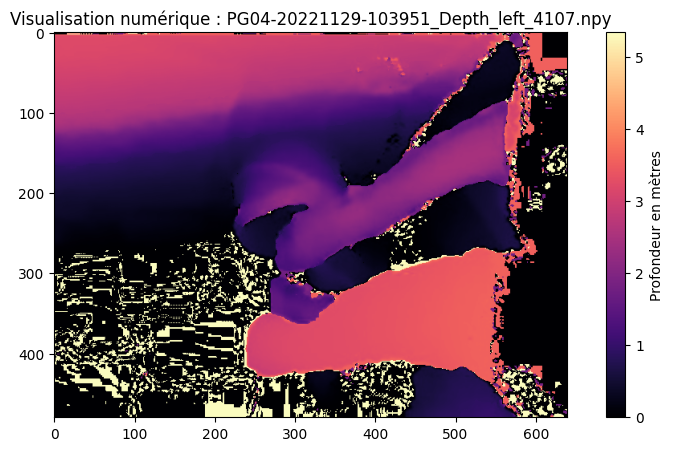

SUCCÈS : Les valeurs sont cohérentes pour l'entraînement.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import random

# Chemin vers les fichiers convertis
test_path = "/content/drive/MyDrive/Colab Notebooks/Code/DL/Depth/datasets/train/Depth_left_m"

if os.path.exists(test_path):
    files = [f for f in os.listdir(test_path) if f.endswith('.npy')]

    if len(files) > 0:
        sample_file = random.choice(files)
        data = np.load(os.path.join(test_path, sample_file))

        print(f"Analyse du fichier : {sample_file}")
        print(f"Dimensions : {data.shape}")
        print(f"Valeur Min : {data.min():.4f} m")
        print(f"Valeur Max : {data.max():.4f} m")
        print(f"Valeur Moyenne : {data.mean():.4f} m")

        # Visualisation
        plt.figure(figsize=(10, 5))
        plt.imshow(data, cmap='magma')
        plt.colorbar(label='Profondeur en mètres')
        plt.title(f"Visualisation numérique : {sample_file}")
        plt.show()

        if data.max() > 300 or data.min() < 0:
            print("ATTENTION : Les valeurs semblent hors normes !")
        else:
            print("SUCCÈS : Les valeurs sont cohérentes pour l'entraînement.")
    else:
        print("Aucun fichier .npy trouvé dans le dossier.")
else:
    print("Dossier introuvable. Vérifiez le chemin.")

In [ ]:
# import os, shutil, cv2
# import numpy as np
# import pandas as pd
# from tqdm import tqdm

# # CONFIGURATION
# BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/Code/DL/Depth/datasets"
# GT_DIR = os.path.join(BASE_DIR, "GT")

# def ensure_dir(p):
#     if not os.path.exists(p): os.makedirs(p, exist_ok=True)

# def assemble():
#     all_rows = []
#     splits = ["train", "val", "test"]

#     ensure_dir(GT_DIR)

#     for split in splits:
#         split_path = os.path.join(BASE_DIR, split)
#         if not os.path.exists(split_path): continue

#         print(f"\n--- Assemblage du split : {split.upper()} ---")

#         # Chemins sources
#         rgb_l_dir = os.path.join(split_path, "Depth_left") # On utilise les JPG originaux
#         depth_l_dir = os.path.join(split_path, "Depth_left_m")
#         mask_dir = os.path.join(split_path, "masks")

#         if not os.path.exists(depth_l_dir):
#             print(f"Saut de {split} : fichiers .npy introuvables.")
#             continue

#         files = [f for f in os.listdir(depth_l_dir) if f.endswith(".npy")]

#         for f in tqdm(files):
#             base_id = f.replace(".npy", "")

#             # Chemins des fichiers
#             img_path = os.path.join(rgb_l_dir, base_id + ".jpg")
#             depth_path = os.path.join(depth_l_dir, f)
#             mask_path = os.path.join(mask_dir, base_id + "_mask.png")

#             # On vérifie que tout le trio existe
#             if os.path.exists(img_path) and os.path.exists(depth_path):
#                 # On récupère les dimensions
#                 img = cv2.imread(img_path)
#                 h, w = img.shape[:2]

#                 all_rows.append({
#                     "Name": base_id,
#                     "Image_Path": os.path.relpath(img_path, BASE_DIR),
#                     "Depth_Path": os.path.relpath(depth_path, BASE_DIR),
#                     "Mask_Path": os.path.relpath(mask_path, BASE_DIR),
#                     "Width": w,
#                     "Height": h,
#                     "Split": split
#                 })

#     # Sauvegarde des CSV
#     df_total = pd.DataFrame(all_rows)
#     for split in splits:
#         df_split = df_total[df_total["Split"] == split]
#         if not df_split.empty:
#             csv_name = os.path.join(GT_DIR, f"{split}_data.csv")
#             df_split.to_csv(csv_name, index=False)
#             print(f"{csv_name} généré ({len(df_split)} entrées)")

# assemble()


--- Assemblage du split : TRAIN ---


100%|██████████| 16182/16182 [1:42:30<00:00,  2.63it/s]



--- Assemblage du split : VAL ---


100%|██████████| 5034/5034 [30:28<00:00,  2.75it/s]



--- Assemblage du split : TEST ---


100%|██████████| 5801/5801 [36:40<00:00,  2.64it/s]


/content/drive/MyDrive/Colab Notebooks/Code/DL/Depth/datasets/GT/train_data.csv généré (16182 entrées)
/content/drive/MyDrive/Colab Notebooks/Code/DL/Depth/datasets/GT/val_data.csv généré (5034 entrées)
/content/drive/MyDrive/Colab Notebooks/Code/DL/Depth/datasets/GT/test_data.csv généré (5801 entrées)


#End Data Engineering

In [ ]:
import os, torch, cv2, json, math, random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from piq import ssim as ssim_func

In [ ]:
# ===============================================================
# 1. CONFIGURATIONS
# ===============================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ROOT = "/content/drive/MyDrive/Colab Notebooks/Code/DL/Depth/datasets"
OUT_DIR = "/content/drive/MyDrive/Colab Notebooks/Code/DL/Depth/models/stereo_resnet101_pipeline"
LOG_FILE = os.path.join(OUT_DIR, "training_metrics.json")
os.makedirs(OUT_DIR, exist_ok=True)

# Hyperparamètres
MAX_RANGE_M = 10.0
LR = 1e-4
EPOCHS = 50
BATCH_SIZE = 2
GRAD_CLIP = 1.0

In [ ]:
class StereoNpyDataset(Dataset):
    def __init__(self, df, root):
        self.df, self.root = df, root
        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((480, 640)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_l = cv2.cvtColor(cv2.imread(os.path.join(self.root, row['Image_Path'])), cv2.COLOR_BGR2RGB)
        img_r = cv2.cvtColor(cv2.imread(os.path.join(self.root, row['Image_Path'].replace('left', 'right'))), cv2.COLOR_BGR2RGB)
        depth = np.load(os.path.join(self.root, row['Depth_Path'])).astype(np.float32)
        depth = cv2.resize(depth, (640, 480), interpolation=cv2.INTER_NEAREST)
        return self.transform(img_l), self.transform(img_r), torch.from_numpy(depth).unsqueeze(0)

class StereoResNet101Depth(nn.Module):
    def __init__(self):
        super().__init__()
        bb = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V2)
        w = bb.conv1.weight.clone()
        bb.conv1 = nn.Conv2d(6, 64, kernel_size=7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            bb.conv1.weight[:, :3], bb.conv1.weight[:, 3:] = w, w
        self.encoder = nn.Sequential(bb.conv1, bb.bn1, bb.relu, bb.maxpool,
                                     bb.layer1, bb.layer2, bb.layer3, bb.layer4)
        self.upsample = nn.Sequential(
            nn.ConvTranspose2d(2048, 512, 2, 2), nn.ReLU(),
            nn.ConvTranspose2d(512, 128, 2, 2),  nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 2, 2),   nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 2, 2),    nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 2, 2),    nn.ReLU(),
            nn.Conv2d(16, 1, 3, padding=1)
        )

    def forward(self, l, r):
        x = torch.cat([l, r], dim=1)
        feat = self.encoder(x)
        out = self.upsample(feat)
        out = F.interpolate(out, size=(480, 640), mode='bilinear', align_corners=False)
        return F.softplus(out) + 1e-6

In [ ]:
# MÉTRIQUES And LOSS
def depth_loss(pred, target, valid):
    if valid.sum() < 1: return torch.tensor(0.0).to(DEVICE)
    diff = torch.abs(pred[valid] - target[valid])
    c = 0.2 * torch.max(diff).item()
    return torch.where(diff <= c, diff, (diff**2 + c**2) / (2 * c)).mean()

def get_metrics(pred, gt, mask):

    pred = pred[mask]
    gt   = gt[mask]

    rmse = torch.sqrt(torch.mean((pred - gt) ** 2)).item()
    mae  = torch.mean(torch.abs(pred - gt)).item()
    absrel = torch.mean(torch.abs(pred - gt) / (gt + 1e-8)).item()

    ratio = torch.max(pred / (gt + 1e-8), gt / (pred + 1e-8))
    delta1 = torch.mean((ratio < 1.25).float()).item()

    return rmse, mae, absrel, delta1


In [ ]:
# ===============================================================
# Entraînement COMPLET
# ===============================================================

train_df = pd.read_csv(os.path.join(ROOT, "GT/train_data.csv"))
val_df   = pd.read_csv(os.path.join(ROOT, "GT/val_data.csv"))

print(f"Loading completed: {len(train_df)} train | {len(val_df)} val")

train_loader = DataLoader(
    StereoNpyDataset(train_df, ROOT),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    StereoNpyDataset(val_df, ROOT),
    batch_size=BATCH_SIZE,
    num_workers=2
)

RESTART_FROM_SCRATCH = False
model = StereoResNet101Depth().to(DEVICE)

CHECKPOINT_PATH = os.path.join(OUT_DIR, 'stereo_checkpoint.pth')

start_epoch = 1
best_rmse = float('inf')
patience_counter = 0
history = []

# ===============================================================
# OPTIMIZER / SCHEDULER / SCALER
# ===============================================================

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler    = torch.amp.GradScaler('cuda')

# ===============================================================
# LOGIQUE DE REPRISE ROBUSTE
# ===============================================================
torch.serialization.add_safe_globals([
    np.dtype,
    np.core.multiarray.scalar,
    np.ndarray,
    type(np.dtype('float64'))
])

try:
    from numpy.dtypes import Float64DType
    torch.serialization.add_safe_globals([Float64DType])
except ImportError:
    pass

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
if not RESTART_FROM_SCRATCH and os.path.exists(CHECKPOINT_PATH):

    print("Resuming training from checkpoint...")

    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)

    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    scaler.load_state_dict(checkpoint['scaler_state_dict'])

    start_epoch = checkpoint['epoch'] + 1
    best_rmse = checkpoint['best_rmse']
    patience_counter = checkpoint['patience_counter']
    history = checkpoint['history']

    print(f"Resumed from epoch {start_epoch}")
    print(f"Best RMSE so far: {best_rmse:.4f}")

else:
    print("Starting fresh training")

# ===============================================================
# TRAINING LOOP
# ===============================================================

PATIENCE = 8
print("Starting training loop...")

for epoch in range(start_epoch, EPOCHS + 1):

    # ----------------- TRAIN -----------------
    model.train()
    tr_loss = 0.0
    pbar = tqdm(train_loader, desc=f'Epoch {epoch}')

    for l, r, d in pbar:

        l, r, d = l.to(DEVICE), r.to(DEVICE), d.to(DEVICE)
        v = (d > 0.1) & (d < MAX_RANGE_M)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda'):
            pred = model(l, r)
            loss = depth_loss(pred, d, v)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        tr_loss += loss.item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    # ----------------- VALIDATION -----------------
    model.eval()

    v_rmse, v_mae, v_absrel, v_delta1 = [], [], [], []

    with torch.no_grad():
        for l, r, d in val_loader:

            l, r, d = l.to(DEVICE), r.to(DEVICE), d.to(DEVICE)
            v = (d > 0.1) & (d < MAX_RANGE_M)

            pred = model(l, r)

            rmse, mae, absrel, delta1 = get_metrics(pred, d, v)

            v_rmse.append(rmse)
            v_mae.append(mae)
            v_absrel.append(absrel)
            v_delta1.append(delta1)

    epoch_metrics = {
        'epoch': epoch,
        'train_loss': tr_loss / len(train_loader),
        'val_rmse': np.mean(v_rmse),
        'val_mae': np.mean(v_mae),
        'val_absrel': np.mean(v_absrel),
        'val_delta1': np.mean(v_delta1)
    }

    history.append(epoch_metrics)

    metrics_path = os.path.join(OUT_DIR, 'training_metrics.json')
    with open(metrics_path, 'w') as f:
        json.dump(history, f, indent=4)

    print(
        f"[{epoch:03d}] "
        f"loss={epoch_metrics['train_loss']:.4f} | "
        f"RMSE={epoch_metrics['val_rmse']:.4f} | "
        f"MAE={epoch_metrics['val_mae']:.4f} | "
        f"AbsRel={epoch_metrics['val_absrel']:.4f} | "
        f"δ<1.25={epoch_metrics['val_delta1']:.4f}"
    )

    # ----------------- EARLY STOPPING -----------------
    if epoch_metrics['val_rmse'] < best_rmse:

        best_rmse = epoch_metrics['val_rmse']
        patience_counter = 0

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'scaler_state_dict': scaler.state_dict(),
            'best_rmse': best_rmse,
            'patience_counter': patience_counter,
            'history': history
        }, CHECKPOINT_PATH)

        print(f"New best model saved (RMSE: {best_rmse:.4f})")

    else:
        patience_counter += 1
        print(f"No improvement ({patience_counter}/{PATIENCE})")

        if patience_counter >= PATIENCE:
            print("Early stopping triggered!")
            break

    scheduler.step()


Loading completed: 16182 train | 5034 val
Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /root/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth


100%|██████████| 171M/171M [00:02<00:00, 81.1MB/s]


Resuming training from checkpoint...
Resumed from epoch 29
Best RMSE so far: 0.2541
Starting training loop...


Epoch 29: 100%|██████████| 8091/8091 [2:10:49<00:00,  1.03it/s, loss=0.0646]


[029] loss=0.0619 | RMSE=0.2533 | MAE=0.0654 | AbsRel=0.0554 | δ<1.25=0.9613
New best model saved (RMSE: 0.2533)


Epoch 30:  68%|██████▊   | 5463/8091 [1:00:15<32:53,  1.33it/s, loss=0.0651]

In [ ]:
def visualize_prediction(model, dataset, device, max_range=MAX_RANGE_M):
    model.eval()

    # Prendre un échantillon aléatoire
    idx = random.randint(0, len(dataset) - 1)
    img_l, img_r, gt_depth = dataset[idx]

    # Préparation pour le modèle (Ajout batch dim)
    input_l = img_l.unsqueeze(0).to(device)
    input_r = img_r.unsqueeze(0).to(device)
    gt_depth_gpu = gt_depth.unsqueeze(0).to(device)

    with torch.no_grad():
        # Inférence
        pred_depth_tensor = model(input_l, input_r)

        valid_mask = (gt_depth_gpu > 0.1) & (gt_depth_gpu < max_range)
        rmse, absrel, d1 = get_metrics(pred_depth_tensor, gt_depth_gpu, valid_mask)

        pred_depth_np = pred_depth_tensor.cpu().squeeze().numpy()

    # Dénormalisation de l'image gauche pour l'affichage (Standard ImageNet)
    img_l_np = img_l.permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_l_np = (img_l_np * std) + mean
    img_l_np = np.clip(img_l_np, 0, 1)

    gt_np = gt_depth.squeeze().numpy()

    # Affichage
    plt.figure(figsize=(20, 7))

    # 1. Image d'entrée
    plt.subplot(1, 3, 1)
    plt.imshow(img_l_np)
    plt.title("Image Gauche (Input)")
    plt.axis('off')

    # 2. Vérité terrain
    plt.subplot(1, 3, 2)
    plt.imshow(gt_np, cmap='magma', vmin=0, vmax=max_range)
    plt.title("Vérité Terrain (GT)")
    plt.colorbar(shrink=0.6, label='Mètres')
    plt.axis('off')

    # 3. Prédiction avec affichage des métriques
    plt.subplot(1, 3, 3)
    plt.imshow(pred_depth_np, cmap='magma', vmin=0, vmax=max_range)
    # On affiche les métriques calculées dans le titre
    plt.title(f"Prédiction\nRMSE: {rmse:.3f}m | AbsRel: {absrel:.3f} | δ<1.25: {d1:.3f}")
    plt.colorbar(shrink=0.6, label='Mètres')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Appel de la fonction
# visualize_prediction(model, val_loader.dataset, DEVICE, max_range=MAX_RANGE_M)

<>:43: SyntaxWarning: invalid escape sequence '\d'
<>:46: SyntaxWarning: invalid escape sequence '\d'
<>:43: SyntaxWarning: invalid escape sequence '\d'
<>:46: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-2734442613.py:43: SyntaxWarning: invalid escape sequence '\d'
  plt.plot(epochs, [d['val_delta1'] for d in data], label='$\delta < 1.25$', color='green', lw=2)
/tmp/ipython-input-2734442613.py:46: SyntaxWarning: invalid escape sequence '\d'
  plt.title('Accuracy ($\delta < 1.25$)')


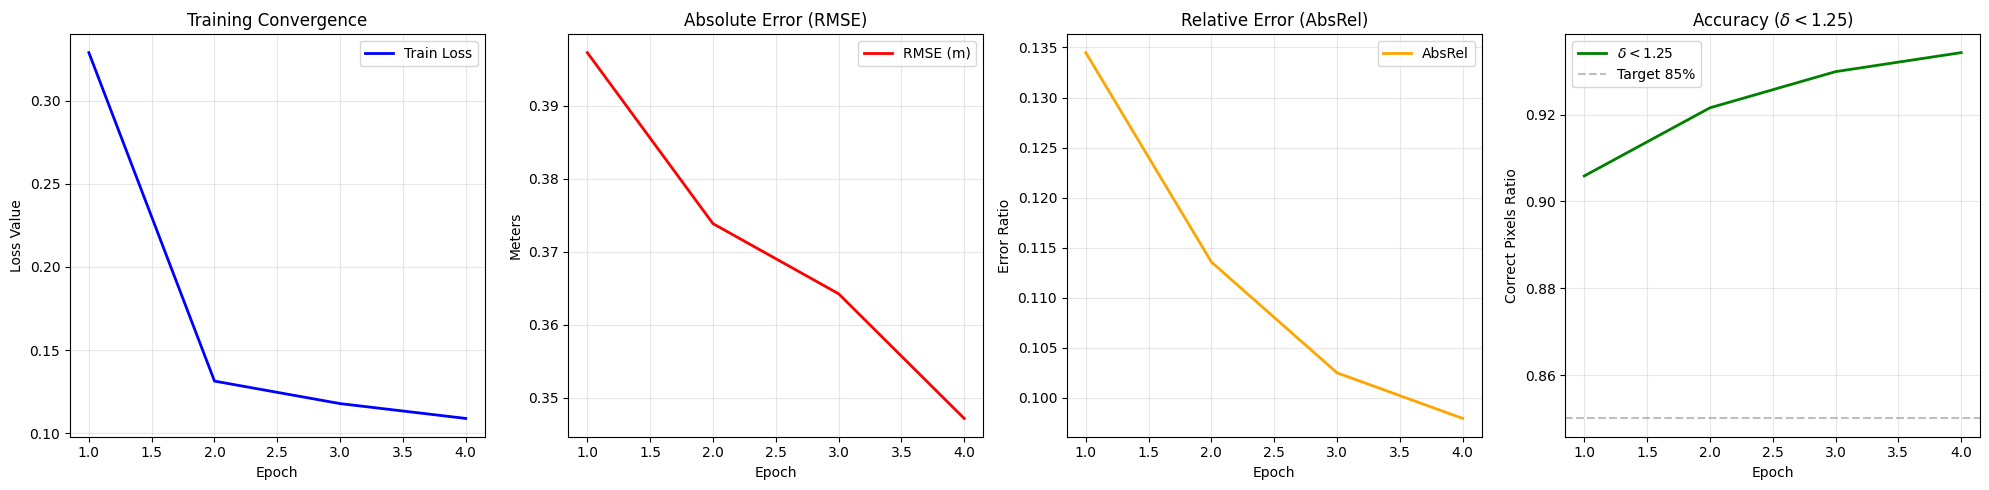

In [ ]:
def plot_training_history(log_path):
    if not os.path.exists(log_path):
        print(f"Error: The file {log_path} does not exist yet.")
        return

    with open(log_path, 'r') as f:
        data = json.load(f)

    epochs = [d['epoch'] for d in data]

    # Set up a 4-panel figure for full analysis
    plt.figure(figsize=(20, 5))

    # 1. Training Loss Curve
    plt.subplot(1, 4, 1)
    plt.plot(epochs, [d['train_loss'] for d in data], label='Train Loss', color='blue', lw=2)
    plt.title('Training Convergence')
    plt.xlabel('Epoch')
    plt.ylabel('Loss Value')
    plt.grid(True, alpha=0.3)
    plt.legend()

    # 2. RMSE Curve (Absolute Error)
    plt.subplot(1, 4, 2)
    plt.plot(epochs, [d['val_rmse'] for d in data], label='RMSE (m)', color='red', lw=2)
    plt.title('Absolute Error (RMSE)')
    plt.xlabel('Epoch')
    plt.ylabel('Meters')
    plt.grid(True, alpha=0.3)
    plt.legend()

    # 3. AbsRel Curve (Relative Error)
    plt.subplot(1, 4, 3)
    plt.plot(epochs, [d['val_absrel'] for d in data], label='AbsRel', color='orange', lw=2)
    plt.title('Relative Error (AbsRel)')
    plt.xlabel('Epoch')
    plt.ylabel('Error Ratio')
    plt.grid(True, alpha=0.3)
    plt.legend()

    # 4. Delta 1 Accuracy Curve (Threshold < 1.25)
    plt.subplot(1, 4, 4)
    plt.plot(epochs, [d['val_delta1'] for d in data], label='$\delta < 1.25$', color='green', lw=2)
    # Reference line for state-of-the-art targets
    plt.axhline(y=0.85, color='gray', linestyle='--', alpha=0.5, label='Target 85%')
    plt.title('Accuracy ($\delta < 1.25$)')
    plt.xlabel('Epoch')
    plt.ylabel('Correct Pixels Ratio')
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

# Appel de la fonction
LOG_FILE = os.path.join(OUT_DIR, 'training_metrics.json')
plot_training_history(LOG_FILE)